DATASET
   invoice_amount  customer_age customer_category  payment_term  \
0         6923388            43         Wholesale            30   
1         7050634            33            Retail            14   
2         4804572            51         Corporate            30   
3         2734489            35            Retail            60   
4         7704212            23         Corporate            30   

   previous_late_count  previous_invoice_count  average_payment_delay  \
0                    0                      14                     10   
1                    2                       4                     16   
2                    1                       9                     13   
3                    4                      13                     19   
4                    2                      18                     18   

   customer_tenure   discount  late  
0                5   1.573972     0  
1                8  12.075103     0  
2                5   3.278634     1 

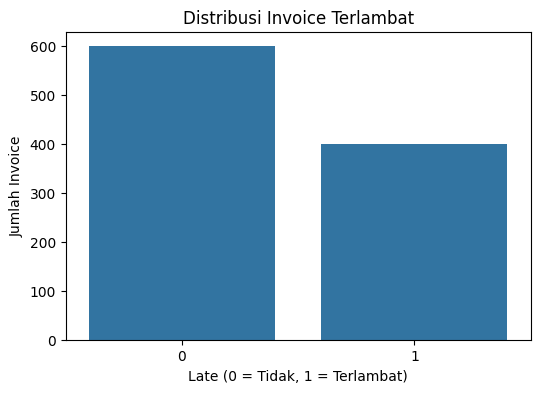


Logistic Regression - Tanpa Penanganan Imbalance
Accuracy : 0.6200
Precision: 0.5400
Recall   : 0.3375
F1 Score : 0.4154

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72       120
           1       0.54      0.34      0.42        80

    accuracy                           0.62       200
   macro avg       0.59      0.57      0.57       200
weighted avg       0.60      0.62      0.60       200


Logistic Regression - Class Weight Balanced
Accuracy : 0.5950
Precision: 0.4950
Recall   : 0.6250
F1 Score : 0.5525

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.57      0.63       120
           1       0.50      0.62      0.55        80

    accuracy                           0.59       200
   macro avg       0.60      0.60      0.59       200
weighted avg       0.62      0.59      0.60       200


PERBANDINGAN MODEL
                                       

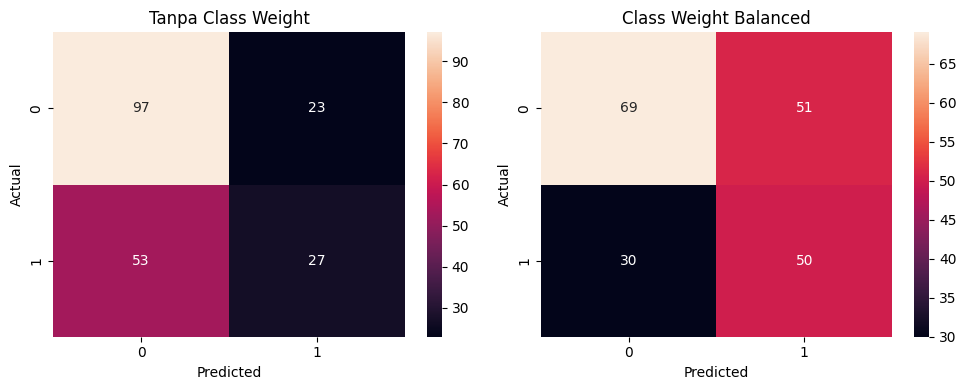


KESIMPULAN

Model dibandingkan sebelum dan sesudah penanganan
class imbalance menggunakan class_weight='balanced'.

Pada kasus prediksi keterlambatan pembayaran invoice,
Recall menjadi metrik penting karena perusahaan ingin
menemukan sebanyak mungkin invoice yang berpotensi
terlambat.

Accuracy yang tinggi saja tidak cukup untuk menyatakan
model baik apabila data memiliki class imbalance.

Model dapat digunakan sebagai decision support untuk
membantu perusahaan mengidentifikasi invoice berisiko.
Keputusan akhir tetap dilakukan oleh manusia.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

n = 1000

data = {
    "invoice_amount": np.random.randint(500_000, 10_000_000, n),

    "customer_age": np.random.randint(20, 60, n),

    "customer_category": np.random.choice(
        ["Retail", "Wholesale", "Corporate"],
        n
    ),

    "payment_term": np.random.choice(
        [14, 30, 60],
        n
    ),

    "previous_late_count": np.random.poisson(
        1.2,
        n
    ),

    "previous_invoice_count": np.random.randint(
        1, 20,
        n
    ),

    "average_payment_delay": np.random.randint(
        0, 20,
        n
    ),

    "customer_tenure": np.random.randint(
        1, 10,
        n
    ),

    "discount": np.random.uniform(
        0, 20,
        n
    )
}

df = pd.DataFrame(data)

# Target dibuat tidak seimbang.
# Sekitar 10-15% invoice dibuat terlambat.

risk_score = (
    df["previous_late_count"] * 0.35
    + df["average_payment_delay"] * 0.08
    + (df["invoice_amount"] / 10_000_000) * 0.2
    + (df["payment_term"] == 60) * 0.3
)

probability = 1 / (1 + np.exp(-(risk_score - 1.8)))

df["late"] = (
    np.random.random(n) < probability
).astype(int)


df.to_csv(
    "invoices.csv",
    index=False
)

print("=" * 60)
print("DATASET")
print("=" * 60)

print(df.head())

print("\nJumlah data:", len(df))

print("\nDistribusi target:")
print(df["late"].value_counts())

print("\nPersentase target:")
print(
    df["late"].value_counts(normalize=True) * 100
)


print("\n" + "=" * 60)
print("DATA INFORMATION")
print("=" * 60)

print(df.info())

print("\nMissing value:")
print(df.isnull().sum())

print("\nDuplikasi:")
print(df.duplicated().sum())


plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="late"
)

plt.title(
    "Distribusi Invoice Terlambat"
)

plt.xlabel(
    "Late (0 = Tidak, 1 = Terlambat)"
)

plt.ylabel(
    "Jumlah Invoice"
)

plt.show()



X = df.drop(
    columns=["late"]
)

y = df["late"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

categorical_features = [
    "customer_category"
]

numeric_features = [
    "invoice_amount",
    "customer_age",
    "payment_term",
    "previous_late_count",
    "previous_invoice_count",
    "average_payment_delay",
    "customer_tenure",
    "discount"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

model_normal = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)


model_normal.fit(
    X_train,
    y_train
)

y_pred_normal = model_normal.predict(
    X_test
)

model_balanced = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)


model_balanced.fit(
    X_train,
    y_train
)

y_pred_balanced = model_balanced.predict(
    X_test
)

def evaluate_model(
    name,
    y_true,
    y_pred
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(
        f"Accuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }


result_normal = evaluate_model(
    "Logistic Regression - Tanpa Penanganan Imbalance",
    y_test,
    y_pred_normal
)

result_balanced = evaluate_model(
    "Logistic Regression - Class Weight Balanced",
    y_test,
    y_pred_balanced
)

results = pd.DataFrame([
    result_normal,
    result_balanced
])

print("\n" + "=" * 60)
print("PERBANDINGAN MODEL")
print("=" * 60)

print(results)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4)
)
cm_normal = confusion_matrix(
    y_test,
    y_pred_normal
)
sns.heatmap(
    cm_normal,
    annot=True,
    fmt="d",
    ax=axes[0]
)
axes[0].set_title(
    "Tanpa Class Weight"
)

axes[0].set_xlabel(
    "Predicted"
)

axes[0].set_ylabel(
    "Actual"
)

cm_balanced = confusion_matrix(
    y_test,
    y_pred_balanced
)

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    ax=axes[1]
)

axes[1].set_title(
    "Class Weight Balanced"
)

axes[1].set_xlabel(
    "Predicted"
)

axes[1].set_ylabel(
    "Actual"
)


plt.tight_layout()

plt.show()

print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)

print("""
Model dibandingkan sebelum dan sesudah penanganan
class imbalance menggunakan class_weight='balanced'.

Pada kasus prediksi keterlambatan pembayaran invoice,
Recall menjadi metrik penting karena perusahaan ingin
menemukan sebanyak mungkin invoice yang berpotensi
terlambat.

Accuracy yang tinggi saja tidak cukup untuk menyatakan
model baik apabila data memiliki class imbalance.

Model dapat digunakan sebagai decision support untuk
membantu perusahaan mengidentifikasi invoice berisiko.
Keputusan akhir tetap dilakukan oleh manusia.
""")